In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
current_dir = os.getcwd()
if current_dir.endswith('notebooks'):
    PROJECT_ROOT = os.path.abspath(os.path.join(current_dir, '..'))
else:
    PROJECT_ROOT = current_dir

DATA_DIR = os.path.join(PROJECT_ROOT, 'data')

In [3]:
DEFECTIVE_DIR = os.path.join(DATA_DIR, 'train', 'defective')
GOOD_DIR = os.path.join(DATA_DIR, 'train', 'good')
GT_DIR = os.path.join(DATA_DIR, 'ground_truth', 'defective')

In [ ]:
def load_sample(image_name, is_defective=True):
    """
    Loads an image and its corresponding ground truth mask from the local file system.
    
    Args:
        image_name (str): The filename of the image (e.g., '000.png').
        is_defective (bool): Determines which folder to look in.
        
    Returns:
        tuple: (RGB image array, Grayscale mask array)
    """
    if is_defective:
        img_path = os.path.join(DEFECTIVE_DIR, image_name)
        mask_name = image_name.replace('.png', '_mask.png')
        mask_path = os.path.join(GT_DIR, mask_name)
    else:
        img_path = os.path.join(GOOD_DIR, image_name)
        mask_path = None
        
    image = cv2.imread(img_path)
    if image is None:
        raise FileNotFoundError(f"Image not found at: {img_path}")
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    if mask_path and os.path.exists(mask_path):
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    else:
        mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)
        
    return image, mask

In [5]:
test_image_name = '000.png'
img, mask = load_sample(test_image_name, is_defective=True)

print(f"Successfully loaded '{test_image_name}'!")
print(f"Image matrix shape: {img.shape}, dtype: {img.dtype}")
print(f"Mask matrix shape:  {mask.shape}, dtype: {mask.dtype}")

Successfully loaded '000.png'!
Image matrix shape: (1024, 1024, 3), dtype: uint8
Mask matrix shape:  (1024, 1024), dtype: uint8


In [ ]:
def segment_toothbrush_advanced(image_rgb):
    hsv = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2HSV)
    h, s, v = cv2.split(hsv)
    
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    enhanced_v = clahe.apply(v)
    
    blurred = cv2.GaussianBlur(enhanced_v, (7, 7), 0)
    
    otsu_thresh, _ = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    adjusted_thresh_val = otsu_thresh * 0.7 
    _, final_thresh = cv2.threshold(blurred, adjusted_thresh_val, 255, cv2.THRESH_BINARY)
    
    kernel = np.ones((21, 21), np.uint8)
    closed_mask = cv2.morphologyEx(final_thresh, cv2.MORPH_CLOSE, kernel)
    
    contours, _ = cv2.findContours(closed_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    filled_mask = np.zeros_like(closed_mask)
    for cnt in contours:
        cv2.drawContours(filled_mask, [cnt], -1, 255, -1)
        
    return filled_mask, enhanced_v

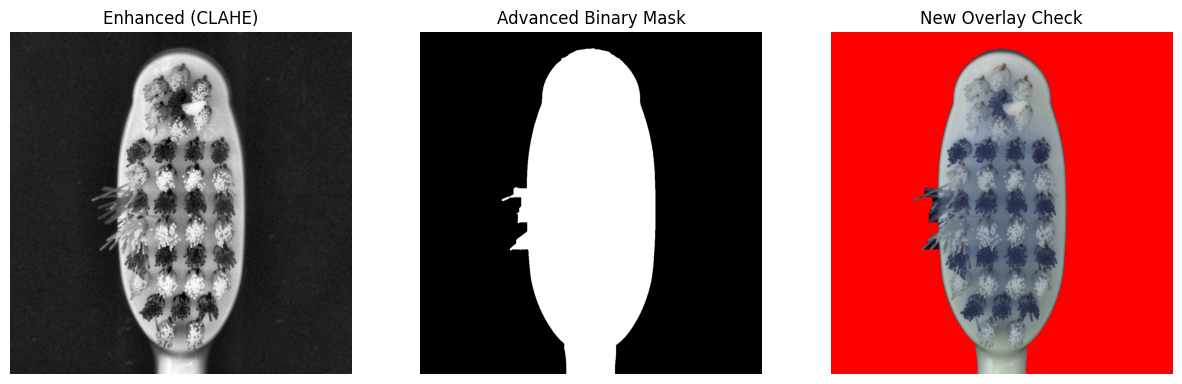

In [25]:
body_mask, enhanced_img = segment_toothbrush_advanced(img)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1); plt.title("Enhanced (CLAHE)"); plt.imshow(enhanced_img, cmap='gray'); plt.axis('off')
plt.subplot(1, 3, 2); plt.title("Advanced Binary Mask"); plt.imshow(body_mask, cmap='gray'); plt.axis('off')
plt.subplot(1, 3, 3); plt.title("New Overlay Check"); overlay = img.copy(); overlay[body_mask == 0] = [255, 0, 0]; plt.imshow(overlay); plt.axis('off')
plt.show()

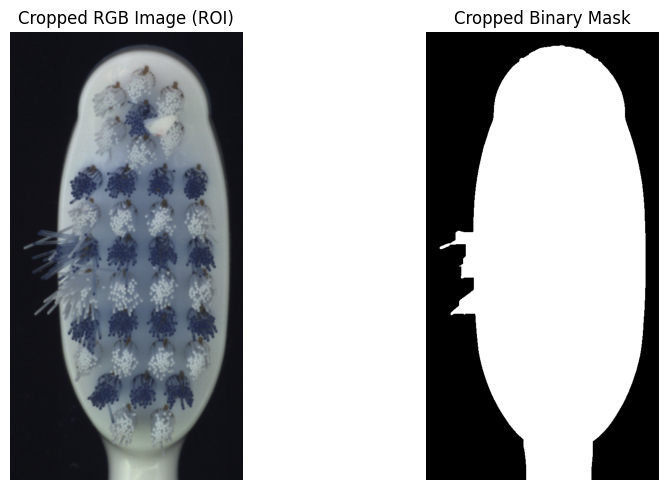

Original image size: (1024, 1024, 3)
Cropped ROI size: (1005, 521, 3)


In [ ]:
def crop_to_roi(image_rgb, binary_mask, padding=20):
    """
    Crops the original image to the Region of Interest (ROI) based on the binary mask.
    
    Args:
        image_rgb (np.ndarray): Original image.
        binary_mask (np.ndarray): Binary mask of the object.
        padding (int): Extra pixels to add around the bounding box.
        
    Returns:
        tuple: (Cropped RGB image, Cropped binary mask, Bounding box coordinates (x,y,w,h))
    """
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if not contours:
        print("Warning: No object found in the mask.")
        return image_rgb, binary_mask, (0, 0, image_rgb.shape[1], image_rgb.shape[0])
    
    largest_contour = max(contours, key=cv2.contourArea)
    
    x, y, w, h = cv2.boundingRect(largest_contour)
    
    x_start = max(0, x - padding)
    y_start = max(0, y - padding)
    x_end = min(image_rgb.shape[1], x + w + padding)
    y_end = min(image_rgb.shape[0], y + h + padding)
    
    cropped_image = image_rgb[y_start:y_end, x_start:x_end]
    cropped_mask = binary_mask[y_start:y_end, x_start:x_end]
    
    return cropped_image, cropped_mask, (x_start, y_start, w, h)

cropped_img, cropped_mask, bbox = crop_to_roi(img, body_mask, padding=30)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Cropped RGB Image (ROI)")
plt.imshow(cropped_img)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Cropped Binary Mask")
plt.imshow(cropped_mask, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

print(f"Original image size: {img.shape}")
print(f"Cropped ROI size: {cropped_img.shape}")

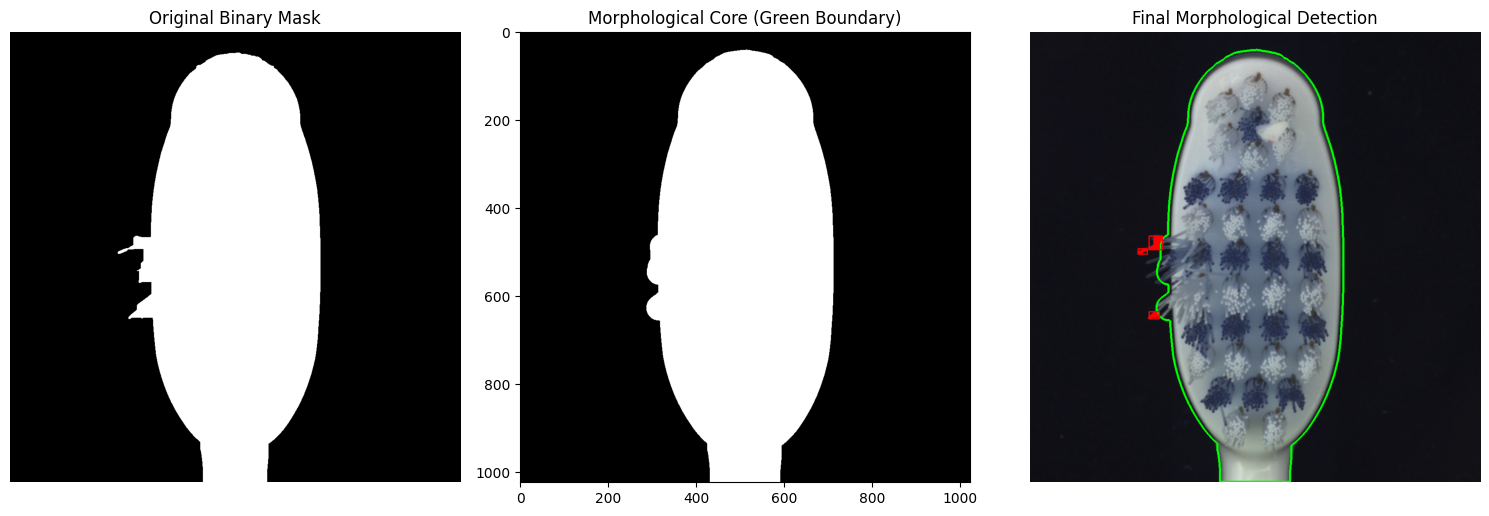

In [ ]:
def detect_external_defects_morph(binary_mask, image_rgb):
    """
    Detects external defects (splaying) using morphological opening to isolate 
    thin protruding structures from the thick main body.
    
    Args:
        binary_mask (np.ndarray): Binary mask of the toothbrush.
        image_rgb (np.ndarray): Original image for visualization.
        
    Returns:
        tuple: (Defect mask, Core body mask, Visualization image)
    """
    kernel_size = 45
    circular_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    
    core_body_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, circular_kernel)
    
    margin_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    core_body_expanded = cv2.dilate(core_body_mask, margin_kernel, iterations=1)
    
    deviation_mask = cv2.bitwise_and(binary_mask, cv2.bitwise_not(core_body_expanded))
    
    noise_kernel = np.ones((5, 5), np.uint8)
    filtered_defect_mask = cv2.morphologyEx(deviation_mask, cv2.MORPH_OPEN, noise_kernel)
    
    vis_img = image_rgb.copy()
    
    contours_core, _ = cv2.findContours(core_body_expanded, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(vis_img, contours_core, -1, (0, 255, 0), 3)
    
    defect_cnts, _ = cv2.findContours(filtered_defect_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for cnt in defect_cnts:
        x, y, w, h = cv2.boundingRect(cnt)
        cv2.rectangle(vis_img, (x, y), (x+w, y+h), (255, 0, 0), 2)
        cv2.drawContours(vis_img, [cnt], -1, (255, 0, 0), -1)
        
    return filtered_defect_mask, core_body_expanded, vis_img

external_defect_mask, core_shape_vis, detection_vis = detect_external_defects_morph(body_mask, img)

plt.figure(figsize=(15, 8))

plt.subplot(1, 3, 1)
plt.title("Original Binary Mask")
plt.imshow(body_mask, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Morphological Core (Green Boundary)")
plt.imshow(core_shape_vis, cmap='gray')

plt.subplot(1, 3, 3)
plt.title("Final Morphological Detection")
plt.imshow(detection_vis)
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import os
import cv2
import numpy as np
from glob import glob

def create_cropped_dataset_fixed(source_dir, dest_dir):
    """
    Processes the dataset: segments the entire toothbrush body to find the Bounding Box,
    then crops both the image and the ground truth mask using this box.
    """
    print(f"Starting FIXED dataset processing from: {source_dir}")
    os.makedirs(dest_dir, exist_ok=True)
    
    subdirs = [
        ('train/defective', 'ground_truth/defective'),
        ('train/good', None)
    ]
    
    for img_subdir, mask_subdir in subdirs:
        img_folder = os.path.join(source_dir, img_subdir)
        dest_img_folder = os.path.join(dest_dir, img_subdir)
        os.makedirs(dest_img_folder, exist_ok=True)
        
        if mask_subdir:
            dest_mask_folder = os.path.join(dest_dir, mask_subdir)
            os.makedirs(dest_mask_folder, exist_ok=True)
            
        if not os.path.exists(img_folder):
            continue
            
        image_paths = glob(os.path.join(img_folder, '*.png'))
        
        for img_path in image_paths:
            filename = os.path.basename(img_path)
            
            img = cv2.imread(img_path)
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            gt_mask = None
            if mask_subdir:
                mask_filename = filename.replace('.png', '_mask.png')
                orig_mask_path = os.path.join(source_dir, mask_subdir, mask_filename)
                if os.path.exists(orig_mask_path):
                    gt_mask = cv2.imread(orig_mask_path, cv2.IMREAD_GRAYSCALE)
            
            if gt_mask is None: 
                gt_mask = np.zeros((img.shape[0], img.shape[1]), dtype=np.uint8)
                
            body_mask, _ = segment_toothbrush_advanced(img_rgb)
            
            contours, _ = cv2.findContours(body_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            
            if contours:
                largest_contour = max(contours, key=cv2.contourArea)
                x, y, w, h = cv2.boundingRect(largest_contour)
                
                padding = 30
                x_start = max(0, x - padding)
                y_start = max(0, y - padding)
                x_end = min(img_rgb.shape[1], x + w + padding)
                y_end = min(img_rgb.shape[0], y + h + padding)
                
                cropped_img = img_rgb[y_start:y_end, x_start:x_end]
                cropped_gt_mask = gt_mask[y_start:y_end, x_start:x_end]
            else:
                cropped_img = img_rgb
                cropped_gt_mask = gt_mask
            
            save_img_path = os.path.join(dest_img_folder, filename)
            cv2.imwrite(save_img_path, cv2.cvtColor(cropped_img, cv2.COLOR_RGB2BGR))
            
            if mask_subdir:
                save_mask_path = os.path.join(dest_mask_folder, filename.replace('.png', '_mask.png'))
                cv2.imwrite(save_mask_path, cropped_gt_mask)
                
    print(f"Successfully created fixed cropped dataset at: {dest_dir}")

DESTINATION_DIR = os.path.join(PROJECT_ROOT, 'data_cropped')
create_cropped_dataset_fixed(DATA_DIR, DESTINATION_DIR)

Starting FIXED dataset processing from: /workspaces/toothbrush-bristle-defect-detection/data
Successfully created fixed cropped dataset at: /workspaces/toothbrush-bristle-defect-detection/data_cropped
